In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

resistance = 10000
# in Ω
capacitance = 10
# in uF
data = pd.read_csv("D:\Capacitance-Discharge Project\scope-data.csv", sep = ',')

Capacitor_A_Avg = (data["Capacitor A max"]+data["Capacitor A min"])/2
Capacitor_V_Avg = (data["Capacitor V max"]+data["Capacitor V min"])/2

data['Capacitor_A_Avg'] = Capacitor_A_Avg
data['Capacitor_V_Avg'] = Capacitor_V_Avg
clean_data_1 = data.drop(["Capacitor V min", "Capacitor V max", "Capacitor A min", "Capacitor A max"], axis = 1)
clean_data_2 = clean_data_1[clean_data_1["time"]>7.840]
clean_data_2

# Discharge filter
# Clean values between 0.25V to 4.75V
discharge = clean_data_2[(clean_data_2["Capacitor_V_Avg"]<4.5) & 
                         (clean_data_2["Capacitor_V_Avg"]>0.5)]
discharge

# Why current is negative?
# During charging, current flows onto the capacitor, so it is +
# During discharging, current flows from capacitor to circuit, so it is -

# Reset time to initial t is 0: 
# No need to create another column and deleting the old one
discharge.assign(
    time = discharge["time"] - discharge["time"].min()
)

,time,Capacitor_A_Avg,Capacitor_V_Avg
615,0.00000,-0.000449,4.486870
616,0.00032,-0.000447,4.472535
617,0.00064,-0.000446,4.458246
618,0.00096,-0.000444,4.444002
619,0.00128,-0.000443,4.429804
...,...,...,...
1296,0.21792,-0.000051,0.507620
1297,0.21824,-0.000051,0.505998
1298,0.21856,-0.000050,0.504381
1299,0.21888,-0.000050,0.502770


Text(0, 0.5, 'Vc')

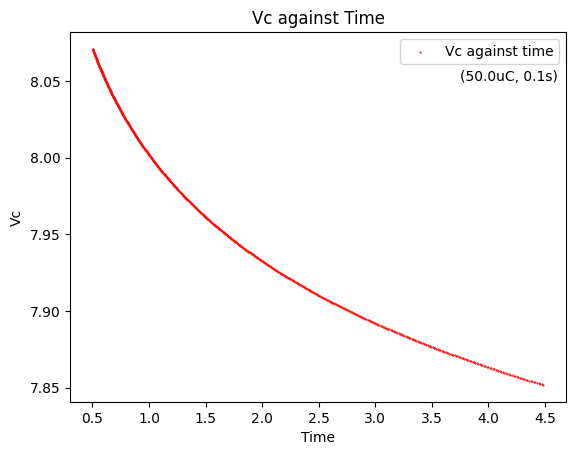

In [31]:
v_values = np.array(discharge['Capacitor_V_Avg'])
time = np.array(discharge['time'])


# Plotting
fig,ax = plt.subplots()
ax.scatter(v_values,time, s = 0.25, label = "Vc against time", color = 'red', linewidths = 1)
ax.legend()


# Values of Data:
voltage_peak = 5
charge = capacitance*voltage_peak
time_constant = resistance*capacitance*10**-6
ax.annotate(
    text = f"({charge:.1f}uC, {time_constant:.1f}s)",
    xy = (3.75,8.05),
)

# data:
ax.set_title("Vc against Time")
ax.set_xlabel("Time")
ax.set_ylabel("Vc")



In [ ]:
# Things to do:
# Plot the ln(V/Vo) against t graph. 
# Use Regression ML to find for tau
# Find Half Life. 
# Find Specific time, and find V, using interpolation (shown in graph.)
# Estimated capacitance
# Initial current
# Current decay
# Energy stored in the capacitor
# Power dissipated by the resistor
# Model accuracy
# Fault detection